# Heart Disease UCI — Exploratory Data Analysis

Dataset: **UCI Heart Disease (Cleveland)** — 303 patients, 13 clinical features, binary target (`1` = heart disease present).

Run `python -m src.data.download && python -m src.data.preprocess` first to materialise `data/processed/heart_disease_clean.csv`.
The same analysis is scripted in `src/eda.py`; this notebook is the interactive companion.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src import config

sns.set_theme(style="whitegrid", palette="deep")
df = pd.read_csv(config.CLEAN_DATA_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (303, 14)


,age,trestbps,chol,thalach,oldpeak,ca,sex,cp,fbs,restecg,exang,slope,thal,target
0,63,145,233,150,2.3,0.0,1,1,1,2,0,3,6.0,0
1,67,160,286,108,1.5,3.0,1,4,0,2,1,2,3.0,1
2,67,120,229,129,2.6,2.0,1,4,0,2,1,2,7.0,1
3,37,130,250,187,3.5,0.0,1,3,0,0,0,3,3.0,0
4,41,130,204,172,1.4,0.0,0,2,0,2,0,1,3.0,0


## Missing value analysis

Only `ca` (major vessels) and `thal` (thalassemia) contain missing values — encoded as `?` in the raw file and converted to `NaN` during cleaning. They are imputed inside the model pipeline (median / most-frequent), never ahead of the train/test split, to avoid leakage.

In [2]:
missing = df.isna().sum().to_frame("missing")
missing["pct"] = (missing["missing"] / len(df) * 100).round(2)
missing[missing["missing"] > 0]

,missing,pct
ca,4,1.32
thal,2,0.66


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2
ca,299.0,0.67,0.94,0.0,0.0,0.0,1.0,3.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0


## Class distribution

54% / 46% split — close to balanced, so accuracy is meaningful and no resampling is required. Stratified splits keep this ratio intact.

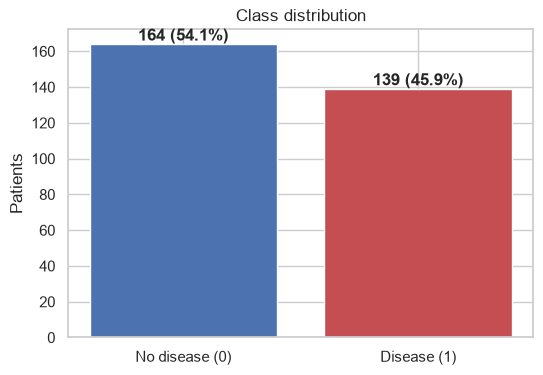

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df[config.TARGET].value_counts().sort_index()
ax.bar(["No disease (0)", "Disease (1)"], counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, f"{v} ({v / len(df):.1%})", ha="center", fontweight="bold")
ax.set_ylabel("Patients")
ax.set_title("Class distribution")
plt.show()

## Numeric feature distributions by target

`thalach` (max heart rate) separates the classes clearly — patients with disease reach lower maximum heart rates. `oldpeak` (ST depression) and `ca` (vessels colored) also shift right for the disease class.

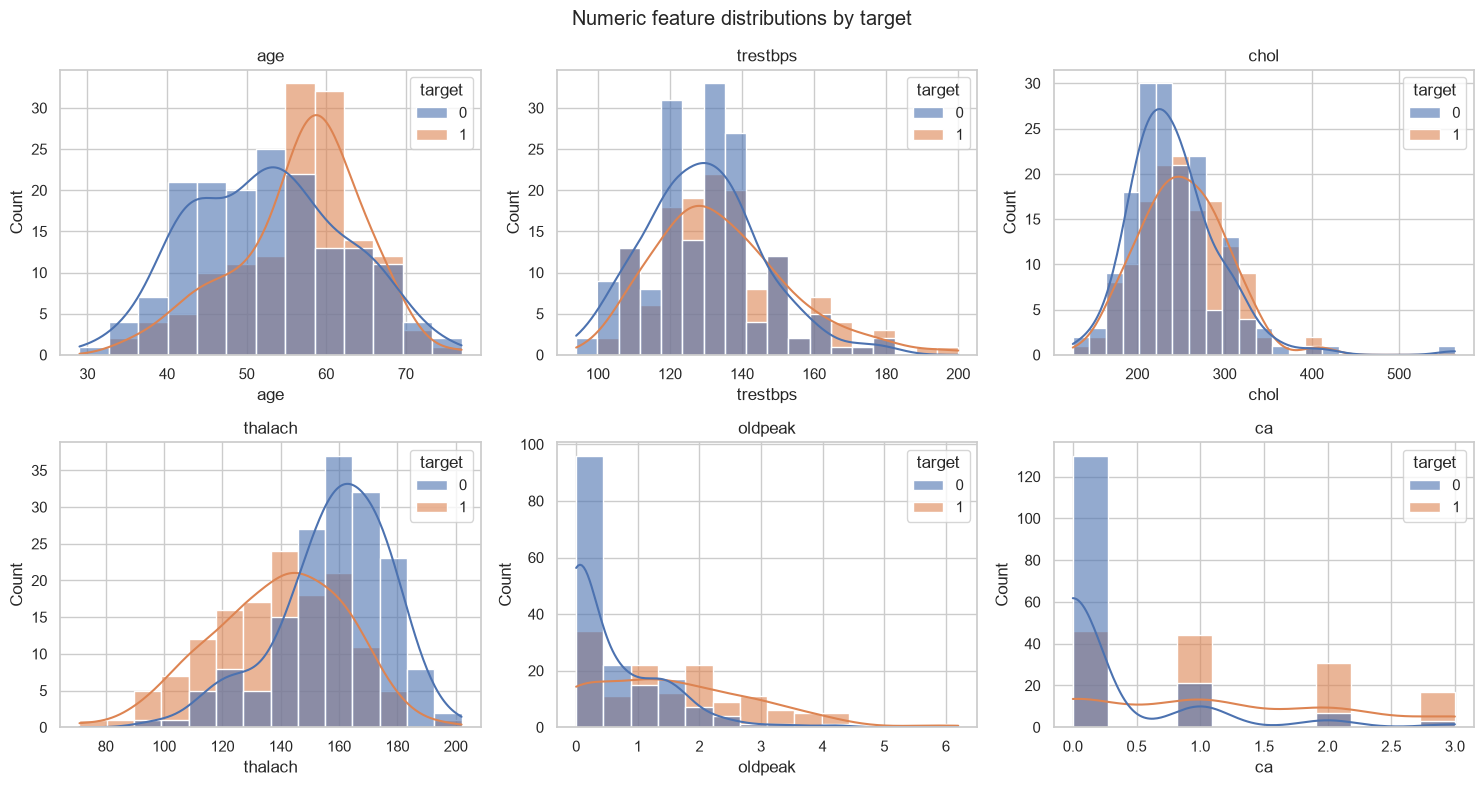

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, config.NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue=config.TARGET, kde=True, ax=ax, alpha=0.6)
    ax.set_title(col)
fig.suptitle("Numeric feature distributions by target")
fig.tight_layout()
plt.show()

## Correlation heatmap

Strongest target correlations: `thal`, `ca`, `oldpeak`, `exang`, `cp` (positive) and `thalach` (negative). No feature pair exceeds |r| ≈ 0.6, so multicollinearity is not a concern.

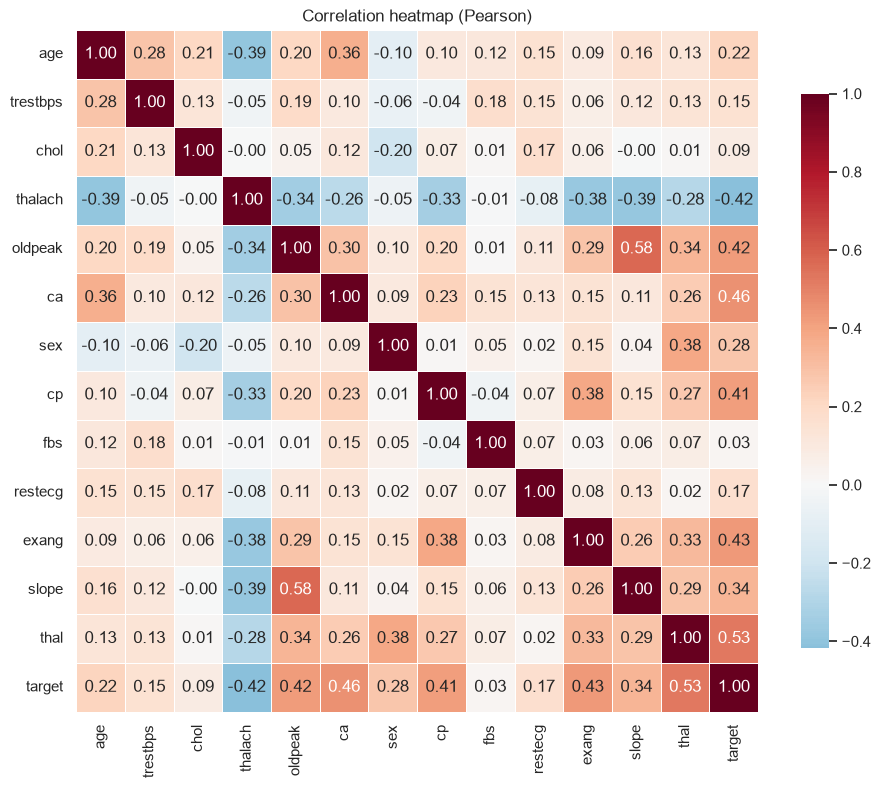

In [6]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation heatmap (Pearson)")
plt.show()

## Disease rate by categorical feature level

Asymptomatic chest pain (`cp = 4`), exercise-induced angina (`exang = 1`), flat/down-sloping ST (`slope ≥ 2`), and reversible-defect thalassemia (`thal = 7`) all carry markedly higher disease rates.

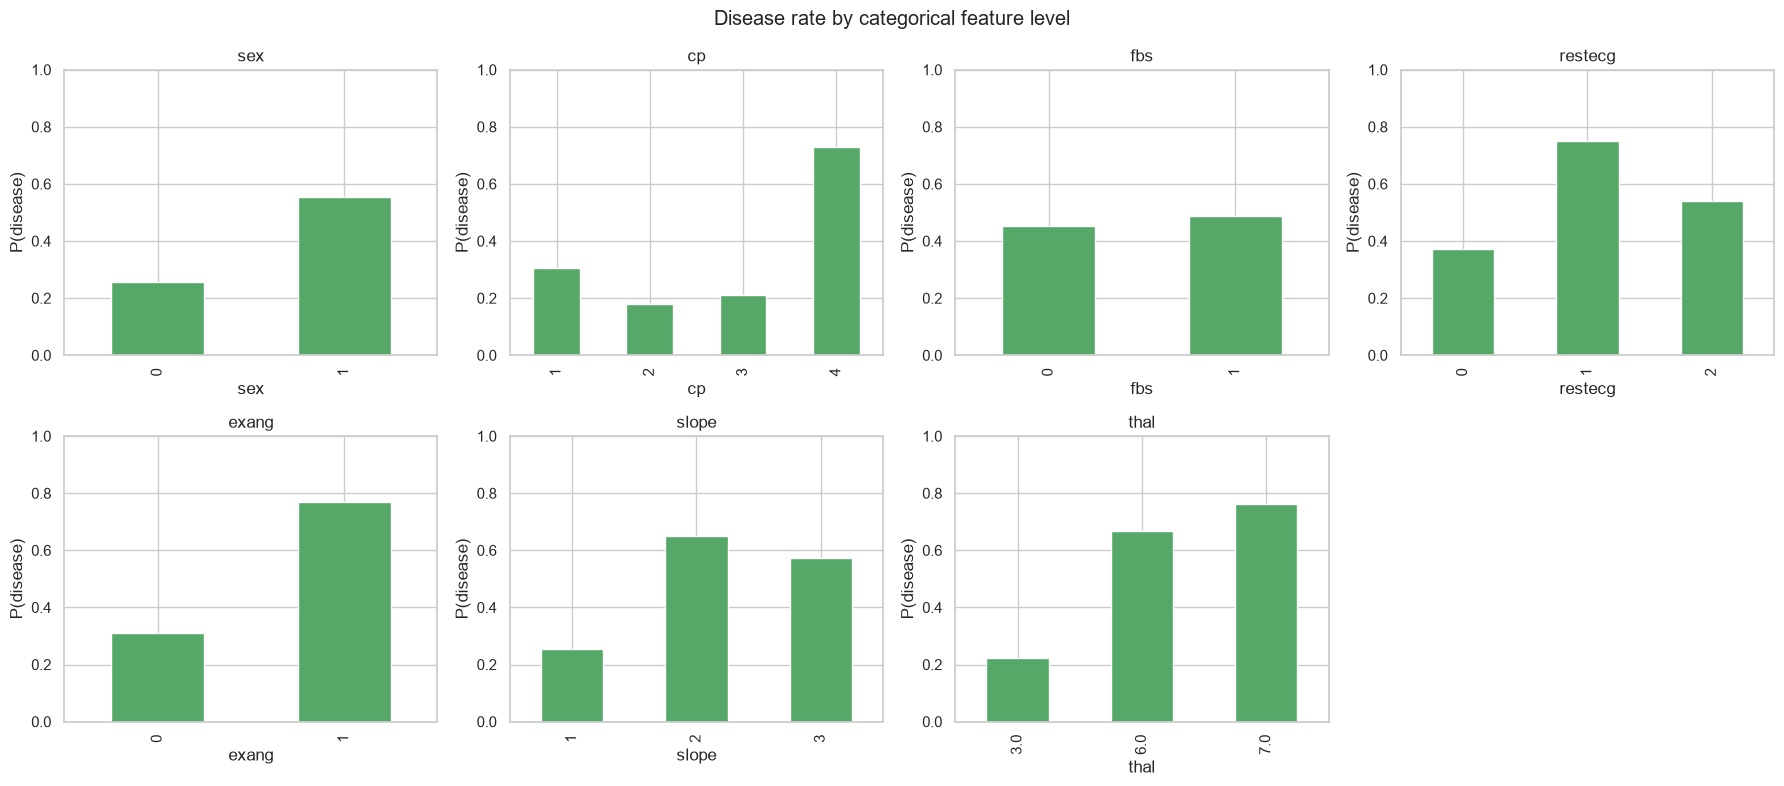

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, config.CATEGORICAL_FEATURES):
    df.groupby(col)[config.TARGET].mean().plot.bar(ax=ax, color="#55a868")
    ax.set_ylabel("P(disease)")
    ax.set_ylim(0, 1)
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.suptitle("Disease rate by categorical feature level")
fig.tight_layout()
plt.show()

## Feature relationships

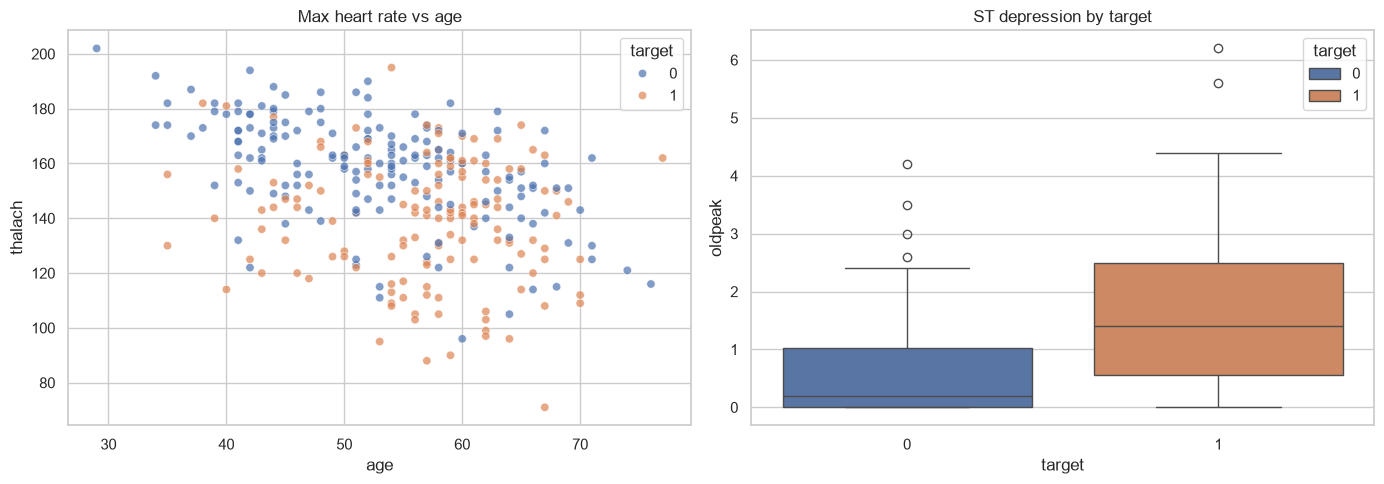

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="age", y="thalach", hue=config.TARGET, alpha=0.7, ax=axes[0])
axes[0].set_title("Max heart rate vs age")
sns.boxplot(data=df, x=config.TARGET, y="oldpeak", hue=config.TARGET, ax=axes[1])
axes[1].set_title("ST depression by target")
fig.tight_layout()
plt.show()

## Key findings

1. **Near-balanced classes** (54/46) — no resampling needed; stratified splitting suffices.
2. **Minimal missingness** — only `ca` (4 rows) and `thal` (2 rows); imputed inside the pipeline.
3. **Strong predictors** — `thal`, `ca`, `oldpeak`, `cp`, `exang`, `thalach` show clear class separation.
4. **No extreme multicollinearity** — all pairwise |r| < 0.65, so all features are retained.
5. **Mixed feature types** — 6 numeric + 7 categorical-coded columns motivate a `ColumnTransformer` with scaling and one-hot encoding.